# 2° Part: MR regularized reconstruction with undersampling
In the previous notebook you've written the image reconstruction function including the regularization term $\lVert \nabla x \rVert^2$. Now copy-paste it here modifying fwdOp and bkwOp for MR using FFT. You will need to modify the computation of $A^T r$ to take into account the "mask" of the k-space (i.e.: don't backProject any data point where you don't have measures!!)

Here, you will try what happens when you undersample the image acquisition, using different schemes, absent any acquisition noise.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
i1 = np.load('testMR.npy')

In [3]:
# Terms related to the spatial regularization
def spatGrad (x__):
    x_grad = np.diff(x__, axis=0, append=0)
    y_grad = np.diff(x__, axis=1, append=0)
    return x_grad,y_grad
def spatAdj (x_grad__, y_grad__):
    x_adj = np.diff(x_grad__, axis=0, prepend=0)
    y_adj = np.diff(y_grad__, axis=1, prepend=0)
    return x_adj + y_adj

# Task 1: Write some undersampling schemes for MR and apply denoising reconstruction

Implement the functions as described in the assignment. 

In [4]:
def fwdOp (x__):
    return np.fft.fft2(x__, norm='ortho')
def bkwdOp (x__):
    # make sure the output is real (it might not be due to some numerical rounding effects)
    return np.fft.ifft2(x__, norm='ortho').real

In [5]:
# Iterative reconstruction with gradient descent
def iterReconMR (i1__,mask__ = None, inImm__ = None, num_iters=100, beta_ =0.1):
    if inImm__ is not None:
        x = inImm__.copy()
    else:
        x = np.zeros_like(i1__).real
    if mask__ is None:
        mask__ = 1
    res = (fwdOp(x) - i1__)
    lossV = np.zeros((num_iters,2))
    for i in range(num_iters):
        # Compute the gradient of the data fidelity term. Note the mask!
        grad_data = bkwdOp(res * mask__)
        # Compute the gradient of the regularization term
        x_grad, y_grad = spatGrad(x)
        grad_reg = spatAdj(x_grad, y_grad)
        # full grad
        grad = grad_data - beta_ * grad_reg
        # Compute the step size (using the exact equation)
        num = np.sum(grad**2)
        grad_fwd = fwdOp(grad)
        gx,gy = spatGrad(grad)
        den = np.sum(np.abs(mask__*grad_fwd)**2) + beta_ * np.sum(gx**2 + gy**2)
        alpha = num / den
        # update the image
        x = x - alpha * grad
        res = res - alpha * grad_fwd
        # Compute the loss
        lossV[i,0] = np.linalg.norm(mask__*res)**2
        lossV[i,1] = np.linalg.norm(grad_reg)**2
    return x,lossV

In [79]:
def regularPointSubSampling (x__, sampling_frac,noiseL):
    data__ = fwdOp(x__)
    maskPr = np.zeros(data__.shape,dtype=bool)
    maskPr[:3,:3] = True
    maskPr[-3:, -3:] = True
    maskPr[:3,-3:] = True
    maskPr[-3:,:3] = True    
    maskPr[::2,::2]=True
    data__ = data__*maskPr
    return data__,maskPr

In [67]:
def regularLineSubsampling (x__,sampling_frac,noiseL):
    data__ = fwdOp(x__)
    maskPr = np.zeros(data__.shape,dtype=bool)
    maskPr[:3,:] = True 
    maskPr[-3:,:] = True 
    maskPr[::4,:]=True
    data__ = data__*maskPr
    return data__,maskPr    

In [8]:
def randomUnifSubSampling (x__, sampling_frac, noiseL = 0):
    data__ = fwdOp(x__)
    maskPr = np.random.uniform(0, 1, size=data__.shape) < sampling_frac
    maskPr[:15,:15] = True
    maskPr[-14:, -14:] = True
    maskPr[:15,-14:] = True
    maskPr[-14:,:15] = True
    data__ = data__ * maskPr
    data__ += np.random.normal(0, noiseL, size=data__.shape)
    print(f"Sampling fraction: {maskPr.sum()/maskPr.size:.1%}")
    return data__,maskPr

In [74]:
def lineUnifSubSampling (x__, sampling_frac, noiseL = 0):
    data__ = fwdOp(x__)
    maskPr = np.random.uniform(0,1,size=data__.shape[0]) < sampling_frac
    maskPr[:5] = True
    maskPr[-4:] = True
    maskPr = np.expand_dims(maskPr, axis=1)
    data__ = data__ * maskPr
    data__ += np.random.normal(0, noiseL, size=data__.shape)
    print(f"Sampling fraction: {maskPr.sum()/maskPr.size:.1%}")
    return data__,maskPr

In [10]:
def lineWeightedSubSampling (x__, sampling_frac, noiseL = 0):
    data__ = fwdOp(x__)
    fv = np.fft.fftfreq(data__.shape[0])
    samplingPr = np.exp(-np.abs(fv)/(.5*sampling_frac))
    maskPr = np.random.uniform(0,1,size=data__.shape[0]) < samplingPr
    maskPr[:9] = True
    maskPr[-8:] = True    
    maskPr = np.expand_dims(maskPr, axis=1)
    data__ = data__ * maskPr
    data__ += np.random.normal(0, noiseL, size=data__.shape)
    print(f"Sampling fraction: {maskPr.sum()/maskPr.size:.1%}")
    return data__,maskPr

In [11]:
def randomWeightedSubSampling (x__, sampling_frac, noiseL = 0):
    data__ = fwdOp(x__)
    print(data__.shape)
    fx = np.fft.fftfreq(data__.shape[0])
    fx = np.expand_dims(fx, axis=1)
    fy = np.fft.fftfreq(data__.shape[1])
    fy = np.expand_dims(fy, axis=0)
    samplingPr = np.exp(-np.sqrt(fx**2+fy**2)/sampling_frac)
    maskPr = np.random.uniform(0,1,size=data__.shape) < samplingPr
    maskPr[:15,:15] = True
    maskPr[-14:, -14:] = True
    maskPr[:15,-14:] = True
    maskPr[-14:,:15] = True    
    data__ = data__ * maskPr
    data__ += np.random.normal(0, noiseL, size=data__.shape)
    print(f"Sampling fraction: {maskPr.sum()/maskPr.size:.1%}")
    return data__,maskPr

Sampling fraction: 27.9%
Sampling fraction: 25.8%
Sampling fraction: 25.8%
(240, 240)
Sampling fraction: 26.0%


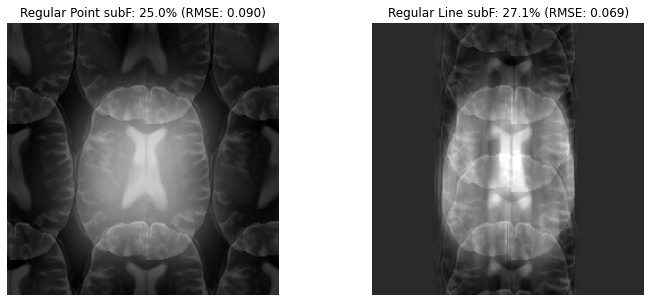

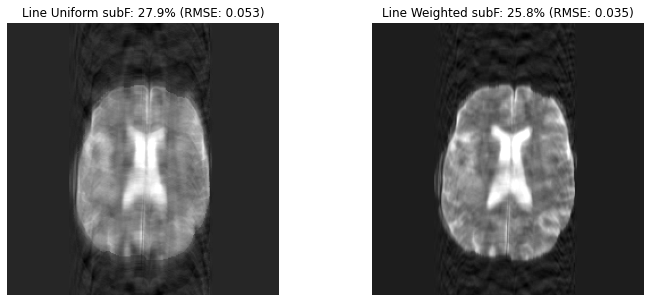

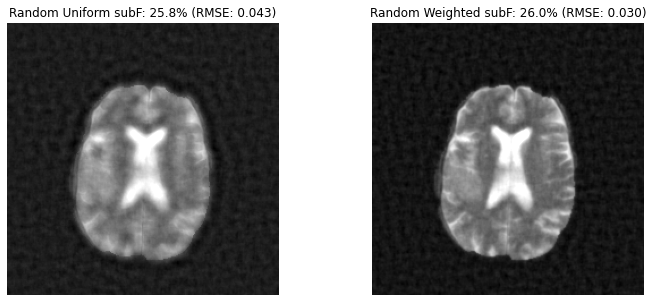

In [80]:
subSamFuncs = [regularPointSubSampling,regularLineSubsampling, lineUnifSubSampling, lineWeightedSubSampling, randomUnifSubSampling, randomWeightedSubSampling]
funcNames = ['Regular Point','Regular Line','Line Uniform', 'Line Weighted', 'Random Uniform', 'Random Weighted']
counter=0

for genF, name in zip(subSamFuncs, funcNames):
    if (counter%2==0):
         plt.figure(figsize=(12,5))
    plt.subplot(1,2,(counter%2)+1)
    data,mask = genF(i1,sampling_frac=.25, noiseL=0.0)
    recImm = np.fft.ifft2(data, norm='ortho').real
    mse = np.sqrt(np.mean((recImm - i1)**2))
    plt.imshow(recImm, cmap='gray',vmax=.8) #,vmin=.1,vmax=0.9)
    subF = mask.sum()/mask.size
    plt.title(f'{name} subF: {subF:.1%} (RMSE: {mse:.3f})')
    counter+=1
    plt.axis('off')
#     plt.xlim(50,150)
#     plt.ylim(150,50)
#    break

## Solutions with (non-optimized) regularized iterative reconstruction

Sampling fraction: 29.6%
Sampling fraction: 27.1%
Sampling fraction: 26.0%
(240, 240)
Sampling fraction: 25.9%


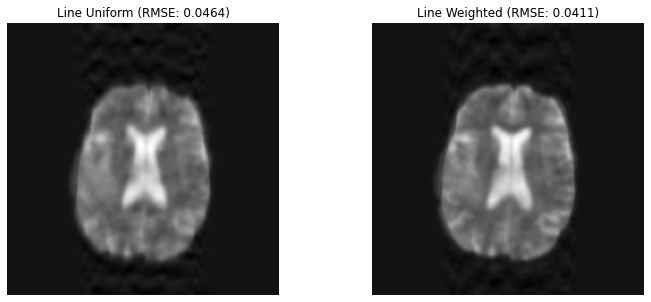

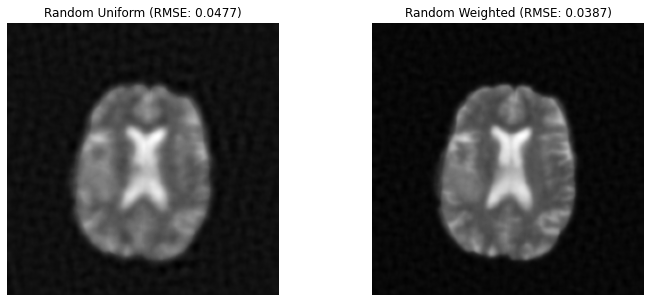

In [26]:
subSamFuncs = [lineUnifSubSampling, lineWeightedSubSampling, randomUnifSubSampling, randomWeightedSubSampling]
funcNames = ['Line Uniform', 'Line Weighted', 'Random Uniform', 'Random Weighted']
counter=0
beta = 2
for genF, name in zip(subSamFuncs, funcNames):
    if (counter%2==0):
         plt.figure(figsize=(12,5))
    plt.subplot(1,2,(counter%2)+1)
    data,mask = genF(i1,sampling_frac=.25, noiseL=0.0)
    recImm,los= iterReconMR(data, mask__=mask, num_iters=200, beta_=beta)
    mse = np.sqrt(np.mean((recImm - i1)**2))
    plt.imshow(recImm, cmap='gray') #,vmin=.1,vmax=0.9)
    plt.title(f'{name} (RMSE: {mse:.4f})')
    counter+=1
    plt.axis('off')
#     plt.xlim(50,150)
#     plt.ylim(150,50)
   # break

## Let's try seeing what we can achieve with different $\beta$ at different subsampling 
1. Use frequency-weighted line subsampling (the best clinically implementable one)
2. Span multiple beta values

**Note:** To compare MSE at different $\beta$ values you need to keep the same specific subsampling of data (otherwise the randomness dominates)




In [60]:
betaL = [1e-3,0.005,0.01,0.03,0.1,0.2,0.4,1]
recV = []
rmseV = []
lossV = []
subValL = [0.1,0.2,0.3,0.4]
anRecL = []
anRecRMSE = []
for alpha in subValL:
    data,mask = randomWeightedSubSampling(i1,sampling_frac=alpha, noiseL=0.0)
    anRec = np.fft.ifft2(data,norm='ortho').real
    anRecL.append(anRec)
    anRecRMSE.append(np.sqrt(np.mean((anRec-i1)**2)))
    for beta in betaL:
        recImm,los= iterReconMR(data, mask__=mask, num_iters=400, beta_=beta)
        recV.append(recImm)
        rmse = np.sqrt(np.mean((recImm - i1)**2))
        rmseV.append(rmse)
        lossV.append(los[-1,0]) # Save the data fidelity term
    

(240, 240)
Sampling fraction: 6.6%
(240, 240)
Sampling fraction: 19.4%
(240, 240)
Sampling fraction: 31.1%
(240, 240)
Sampling fraction: 41.2%


In [61]:
recV = np.array(recV)
recM = recV.reshape(len(subValL), len(betaL), 240, 240)
anRecV = np.array(anRecL)


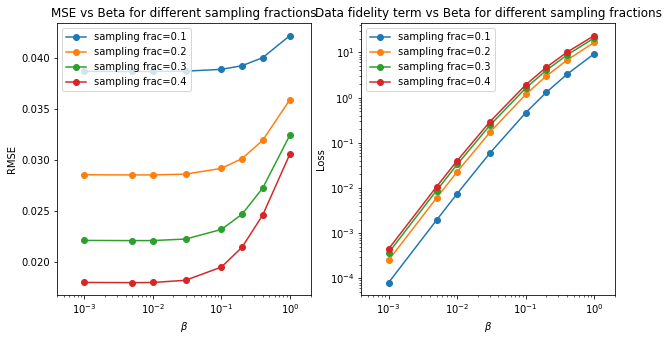

In [62]:
lossV = np.array(lossV).reshape(len(subValL), len(betaL))
rmseV = np.array(rmseV).reshape(len(subValL), len(betaL))
plt.figure(figsize=(10,5))
plt.subplot(121)
plt.plot(betaL,rmseV.T,'o-')
plt.legend([f'sampling frac={alpha}' for alpha in subValL])
plt.xscale('log')
plt.xlim(4e-4,2)
plt.title('MSE vs Beta for different sampling fractions')
plt.ylabel('RMSE')
plt.xlabel(r'$\beta$')
plt.subplot(122)
plt.plot(betaL,lossV.T,'o-')
plt.legend([f'sampling frac={alpha}' for alpha in subValL])
plt.xscale('log')
plt.xlim(4e-4,2)
plt.title('Data fidelity term vs Beta for different sampling fractions')
plt.ylabel('Loss')
plt.xlabel(r'$\beta$')
plt.yscale('log')

### Show the image with the best MSE  (over $\beta$) at all different subsamplings

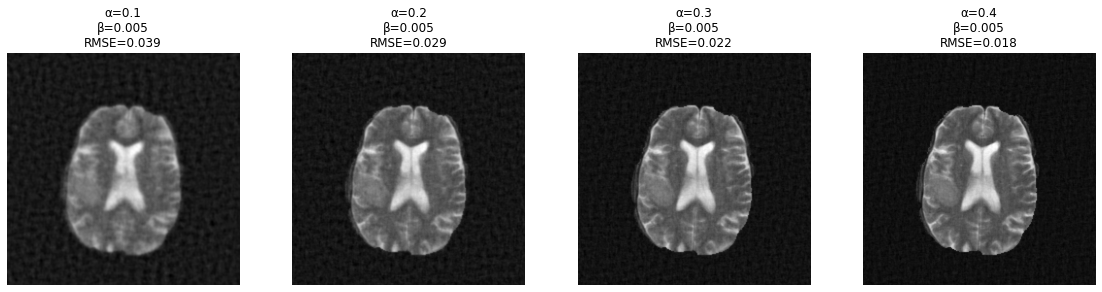

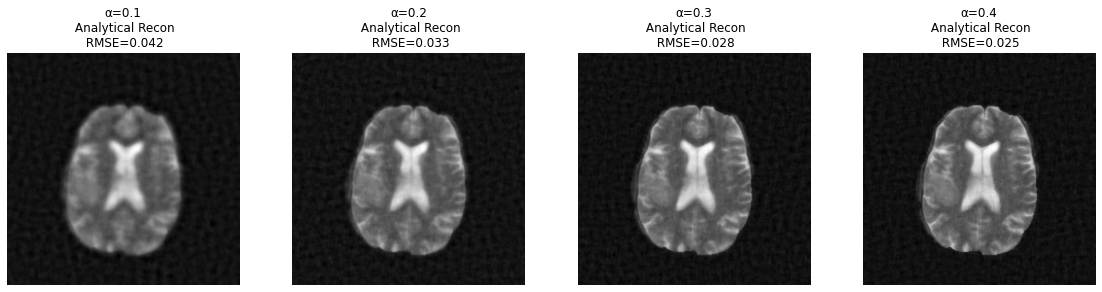

In [63]:

fig, axs = plt.subplots(1, len(subValL), figsize=(4*len(subValL), 4))
for i, alpha in enumerate(subValL):
    j_best = np.argmin(rmseV[i])
    axs[i].imshow(recM[i, j_best,:,:], cmap='gray') #,vmin=0.1, vmax=0.9)
    # axs[i].set_xlim(50,150)
    # axs[i].set_ylim(150,50)
    axs[i].set_title(f"α={alpha}\nβ={betaL[j_best]}\nRMSE={rmseV[i,j_best]:.3f}")
    axs[i].axis('off')
plt.tight_layout()
plt.show()

fig, axs = plt.subplots(1, len(subValL), figsize=(4*len(subValL), 4))
for i, alpha in enumerate(subValL):
    axs[i].imshow(anRecV[i,:,:].real, cmap='gray') #,vmin=0.1, vmax=0.9)
    # axs[i].set_xlim(50,150)
    # axs[i].set_ylim(150,50)
    axs[i].set_title(f"α={alpha}\n Analytical Recon\n RMSE={anRecRMSE[i]:.3f}")
    axs[i].axis('off')
plt.tight_layout()
plt.show()

        

### Results comment:
Note that the data fidelity term of the reconstruction is $0$ for all practical purposes!<br> ($10^-3$ summed over $>50k$ k-space elements!!)<br>
What the regularization is doing, even at very low $\beta$ values is just selecting one specific image over the multiple ones with identical Fourier transform in the sampled elemets!<br>
Nonetheless, the regularization does not seem to help. The stronger you make it, the worse the MSE is!



### Show images at dfferent $\beta$ for the 20% subsampling

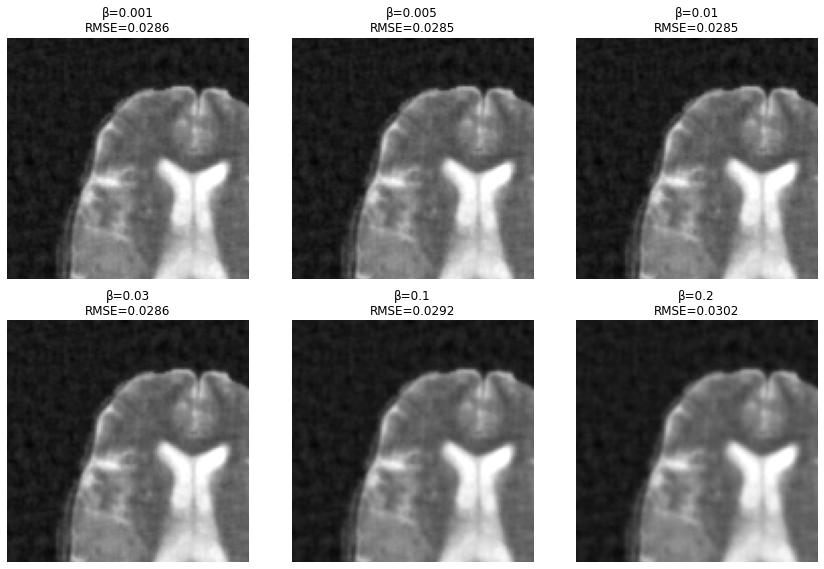

In [78]:
rows = 2
cols = 3   # last cell unused

fig, axs = plt.subplots(rows, cols, figsize=(4*cols, 4*rows))
axs = axs.flatten()
startB = 0
for i, beta in enumerate(betaL[startB:]):
    axs[i].imshow(recM[1, i+startB], cmap='gray', vmin=-0.1, vmax=0.9)
    axs[i].set_xlim(30,150)
    axs[i].set_ylim(150,30)
    axs[i].set_title(f"β={beta}\nRMSE={rmseV[1,i+startB]:.4f}")
    axs[i].axis('off')
    if i>4:
        break

# hide the unused 8th axis
axs[-1].axis('off')

plt.tight_layout()
plt.show()


1. It turns out that against this very structured noise there is not much effectiveness in using $\lVert \nabla x \rVert^2$ regularization. It starts smoothing out edges much earlier that it starts to suppress this "noise"

## Now try to see what happens if instead you want to suppress noise

In [28]:
betaL = [0.005,0.01,0.03 ,0.1,0.2,0.4,1]
recV = []
rmseV = []
lossV = []
subValL = [2]
for alpha in subValL:
    data,mask = lineWeightedSubSampling(i1,sampling_frac=alpha, noiseL=0.03)
    for beta in betaL:
        recImm,los= iterReconMR(data, mask__=mask, num_iters=300, beta_=beta)
        recV.append(recImm)
        rmse = np.sqrt(np.mean((recImm - i1)**2))
        rmseV.append(rmse)
        lossV.append(los[-1,0]+beta*los[-1,1])
    

Sampling fraction: 78.3%


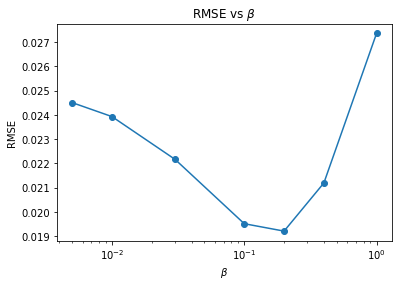

In [30]:
plt.plot(betaL,rmseV,'o-')
plt.xscale('log')
plt.xlabel(r'$\beta$')
plt.ylabel('RMSE')
_= plt.title(r'RMSE vs $\beta$')

In [31]:
recV = np.array(recV)
recM = recV.reshape(len(subValL), len(betaL), 240, 240)
rmseV = np.array(rmseV).reshape(len(subValL), len(betaL))

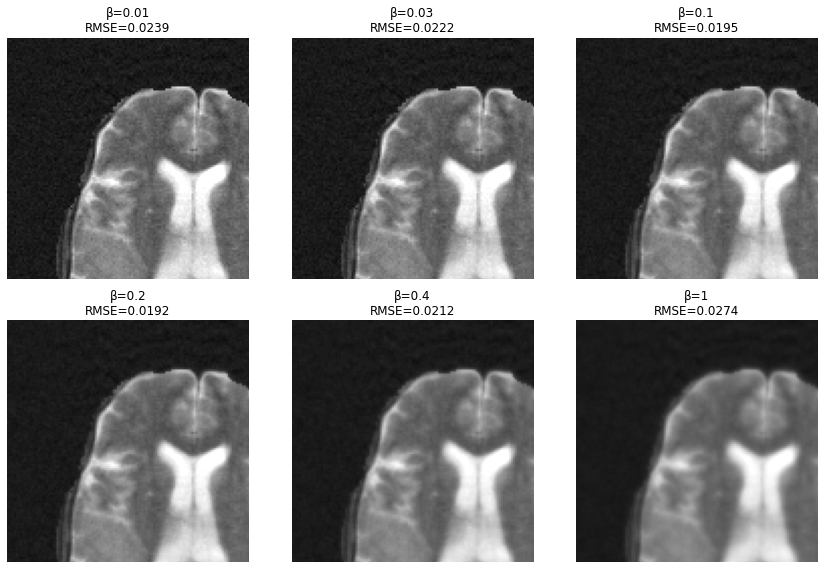

In [32]:


rows = 2
cols = 3   # last cell unused

fig, axs = plt.subplots(rows, cols, figsize=(4*cols, 4*rows))
axs = axs.flatten()
sBeta = 1
for i, beta in enumerate(betaL[sBeta:]):
    axs[i].imshow(recM[0, i+sBeta], cmap='gray', vmin=-0.1, vmax=0.9)
    axs[i].set_xlim(30,150)
    axs[i].set_ylim(150,30)
    axs[i].set_title(f"β={beta}\nRMSE={rmseV[0,i+sBeta]:.4f}")
    axs[i].axis('off')

# hide the unused 8th axis
axs[-1].axis('off')

plt.tight_layout()
plt.show()